In [1]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.config import SolverConfig
from src.models.spacecraft import Spacecraft
from src.models.body import Body
from src.optimizer import Optimizer
from src.utils import cart2eq, cart2kep

from scripts.ephemerides import load_states

earth_path = "../src/horizons_results_earth_heliocentric_state_vector.txt"
mars_path = "../src/horizons_results_mars_heliocentric_state_vector.txt"

earth_loc, earth_dt = load_states(earth_path)
mars_loc, mars_dt = load_states(mars_path)

earth_loc = earth_loc*1e3
mars_loc = mars_loc*1e3

cfg = SolverConfig()
Earth = Body(name="earth",mu=3.986e14)
Mars = Body(name="mars",mu=4.283e13)
Sun = Body(name="sun",mu=1.327e20)


=== TOF 500 days ===
Departure 300 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 310 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 320 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 330 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 340 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 350 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 360 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 370 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 380 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 390 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 400 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 410 days
--- SWITCHING TO PHASE 2 (PHASING) ---
  Failed convergence
Departure 420 days
--- SWITCHI

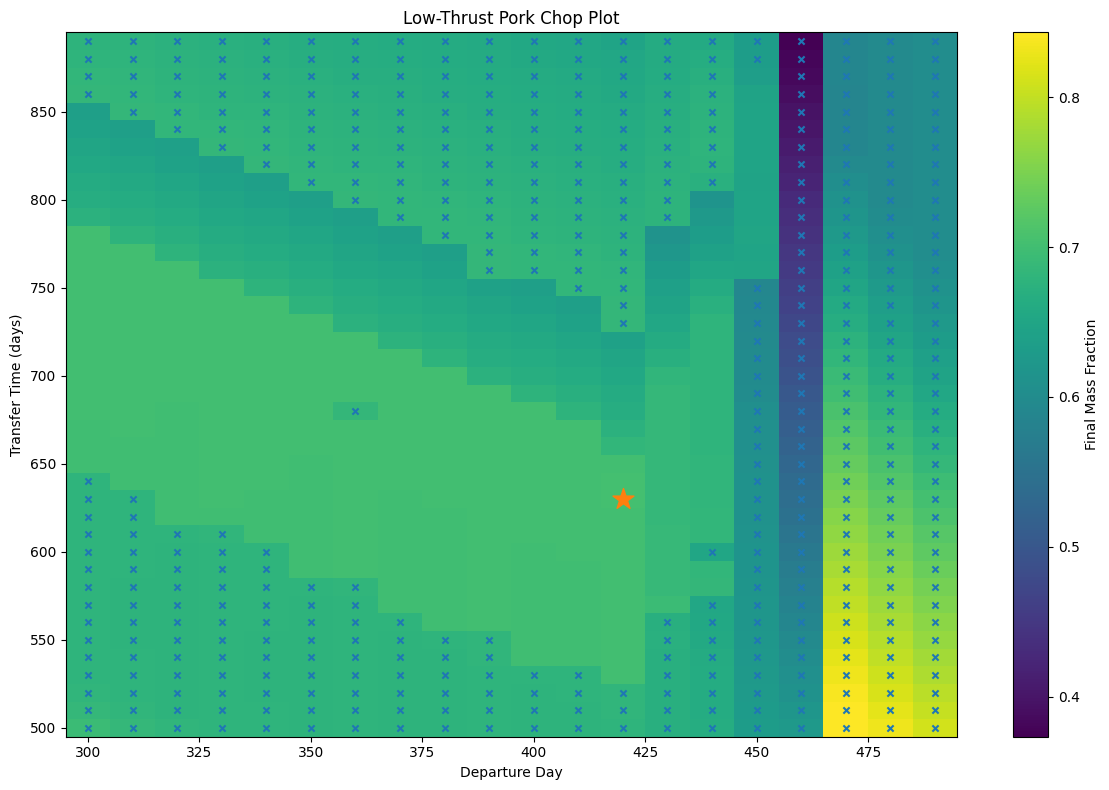


Saved pork chop plot.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# USER SETTINGS
# ============================================================

departures = np.arange(300, 500, 10, dtype=int)      # departure days
tf_days   = np.arange(500, 900, 10, dtype=int)       # transfer times

save_dir = Path("porkchop_results")
save_dir.mkdir(exist_ok=True)

# ============================================================
# STORAGE ARRAYS
# ============================================================

# Metrics
final_mass_grid = np.full((len(tf_days), len(departures)), np.nan)
mass_fraction_grid = np.full_like(final_mass_grid, np.nan)
converged_grid = np.zeros_like(final_mass_grid, dtype=bool)

# Optional: store errors
mee_error_grid = np.full((len(tf_days), len(departures)), np.nan)
kep_error_grid = np.full((len(tf_days), len(departures)), np.nan)

# Best solution tracking
best_mf = -np.inf
best_departure = None
best_tf = None
best_sol = None
best_fw_ts = None

# ============================================================
# MAIN LOOP
# ============================================================

for j, tf in enumerate(tf_days):

    print(f"\n=== TOF {tf} days ===")

    for i, t0 in enumerate(departures):

        print(f"Departure {t0} days")

        try:

            # ------------------------------------------------
            # Initial / target states
            # ------------------------------------------------

            Psyche = Spacecraft()
            m0 = Psyche.m0

            r0v0 = earth_loc[t0]
            y0 = np.hstack((r0v0, m0))

            rfvf = mars_loc[t0 + tf]
            yf = np.hstack((rfvf, m0))

            # ------------------------------------------------
            # Build target orbit
            # ------------------------------------------------

            fw_target = cart2eq(rfvf, Sun.mu)[0:6]

            fw_opt = Optimizer(
                cfg,
                Psyche,
                target_orbit=fw_target
            )

            fw_opt.controller.gains.nominal_throttle = 0.8

            # ------------------------------------------------
            # Propagate
            # ------------------------------------------------

            (
                fw_ts,
                fw_sol,
                fw_as,
                fw_es,
                fw_thist,
                fw_uhist,
                fw_qhist
            ) = fw_opt.simulate_forward(
                t0 * 86400,
                tf * 86400,
                y0,
                mars_loc
            )

            # ------------------------------------------------
            # Final state analysis
            # ------------------------------------------------

            final_mass = fw_sol[6, -1]

            mee_error = (
                np.array(cart2eq(fw_sol[0:6, -1], Sun.mu))
                - np.array(fw_opt.true_target)
            )

            kep_error = (
                np.array(cart2kep(fw_sol[0:6, -1], Sun.mu))
                - np.array(cart2kep(rfvf, Sun.mu))
            )

            mee_norm = np.linalg.norm(mee_error)
            kep_norm = np.linalg.norm(kep_error)

            # ------------------------------------------------
            # Save metrics
            # ------------------------------------------------

            final_mass_grid[j, i] = final_mass
            mass_fraction_grid[j, i] = final_mass / m0
            mee_error_grid[j, i] = mee_norm
            kep_error_grid[j, i] = kep_norm

            # ------------------------------------------------
            # Convergence
            # ------------------------------------------------

            converged = fw_opt.check_converge(fw_sol[0:6, -1])

            converged_grid[j, i] = converged

            if converged:

                mass_consumed = m0 - final_mass

                print(
                    f"  Converged | "
                    f"mf={final_mass:.2f} kg | "
                    f"dm={mass_consumed:.2f} kg"
                )

                # --------------------------------------------
                # Track best
                # --------------------------------------------

                if final_mass > best_mf:

                    best_mf = final_mass
                    best_departure = t0
                    best_tf = tf

                    best_sol = fw_sol.copy()
                    best_fw_ts = fw_ts.copy()

                    print("  >>> NEW BEST <<<")

            else:
                print("  Failed convergence")

        except Exception as e:

            print(f"  FAILED: {e}")

# ============================================================
# SAVE RAW PORKCHOP DATA
# ============================================================

np.savez(
    save_dir / "porkchop_data.npz",

    departures=departures,
    tf_days=tf_days,

    final_mass_grid=final_mass_grid,
    mass_fraction_grid=mass_fraction_grid,
    converged_grid=converged_grid,

    mee_error_grid=mee_error_grid,
    kep_error_grid=kep_error_grid
)

print("\nSaved pork chop data.")

# ============================================================
# SAVE BEST TRAJECTORY
# ============================================================

if best_sol is not None:

    np.savez(
        save_dir / "best_transfer.npz",

        ts=best_fw_ts,
        sol=best_sol,

        departure=best_departure,
        tof=best_tf,

        final_mass=best_mf
    )

    print("\n=== BEST SOLUTION ===")
    print(f"Departure: {best_departure} days")
    print(f"TOF:       {best_tf} days")
    print(f"Arrival:   {best_departure + best_tf} days")
    print(f"Final mf:  {best_mf:.2f} kg")

# ============================================================
# PORK CHOP PLOT
# ============================================================

X, Y = np.meshgrid(departures, tf_days)

plt.figure(figsize=(12, 8))

pcm = plt.pcolormesh(
    X,
    Y,
    mass_fraction_grid,
    shading='auto'
)

plt.colorbar(pcm, label='Final Mass Fraction')

# Overlay failed points
failed = ~converged_grid

plt.scatter(
    X[failed],
    Y[failed],
    marker='x',
    s=20
)

# Best point
if best_departure is not None:

    plt.scatter(
        best_departure,
        best_tf,
        marker='*',
        s=250
    )

plt.xlabel("Departure Day")
plt.ylabel("Transfer Time (days)")
plt.title("Low-Thrust Pork Chop Plot")

plt.tight_layout()
plt.savefig(save_dir / "porkchop_plot.png", dpi=300)

plt.show()

print("\nSaved pork chop plot.")